# MGMT298D: Science and Strategy of AI
### Week 3 - Clustering and Collaborative Filtering
### Application: Netflix Recommendations

## Import Libraries and Data

In [3]:
# Import necessary libraries for clustering, similarity, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("https://raw.githubusercontent.com/ucla-anderson-SSAI/SSAI/refs/heads/main/netflix_ratings.csv")
print(f"Users: {len(df):,} | Movies: {df.shape[1] - 1}")

# Fill missing ratings with movie averages, standardize for clustering
data_filled = df.fillna(df.mean(numeric_only=True))
X = data_filled.drop("user_id", axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Users: 5,000 | Movies: 100


## Visualizing Clusters: Two Contrasting Movies

Movies selected: 'Armageddon' vs 'Lost in Translation'
Users who rated both movies: 5,000 out of 5,000


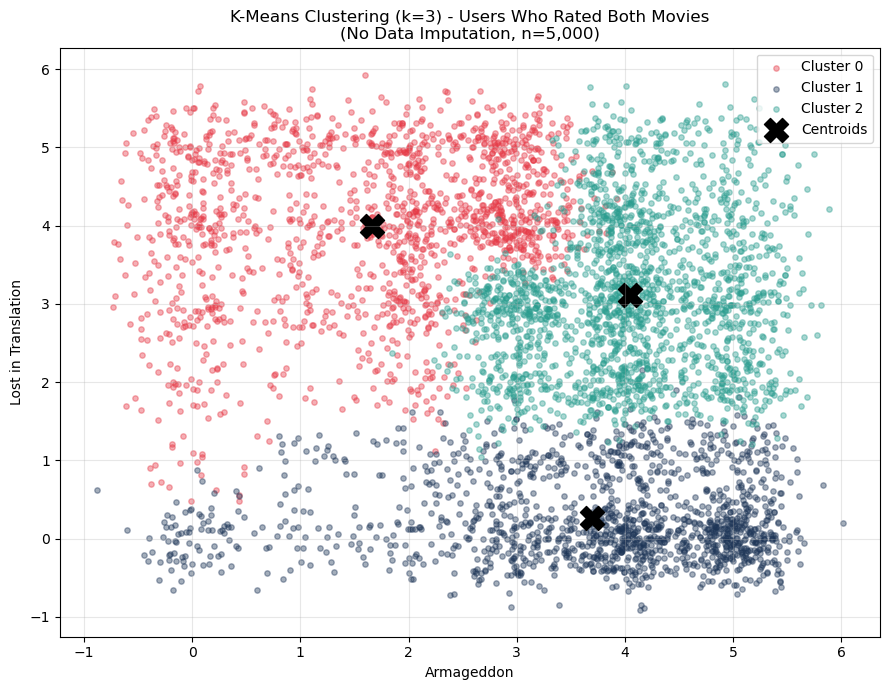

In [5]:
# Sample users who have rated BOTH movies (no imputation)
# Use original df (before imputation) to find movies with lowest correlation
movie_cols = df.columns.drop("user_id")
corr_matrix = df[movie_cols].corr()
np.fill_diagonal(corr_matrix.values, 0)  # Ignore self-correlation
movie1, movie2 = corr_matrix.stack().idxmin()

# Only keep users who have rated BOTH movies (no imputation)
both_rated_mask = df[movie1].notna() & df[movie2].notna()
X_both = df.loc[both_rated_mask, [movie1, movie2]].values

print(f"Movies selected: '{movie1}' vs '{movie2}'")
print(f"Users who rated both movies: {len(X_both):,} out of {len(df):,}")

# Run k-means on users with both ratings
kmeans_2d = KMeans(n_clusters=3, random_state=42, n_init="auto")
labels_2d = kmeans_2d.fit_predict(X_both)
centers = kmeans_2d.cluster_centers_

# Add jitter for visibility (ratings are discrete 1-5)
np.random.seed(42)
jitter = np.random.normal(0, 0.3, X_both.shape)
X_jittered = X_both + jitter

plt.figure(figsize=(9, 7))
colors = ["#e63946", "#1d3557", "#2a9d8f"]
for i in range(3):
    mask = labels_2d == i
    plt.scatter(X_jittered[mask, 0], X_jittered[mask, 1], c=colors[i], label=f"Cluster {i}", alpha=0.3, s=20)

plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=300, label="Centroids")
plt.xlabel(movie1)
plt.ylabel(movie2)
plt.title(f"K-Means Clustering (k=3) - Users Who Rated Both Movies\n(No Data Imputation, n={len(X_both):,})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Finding k (Elbow Method)

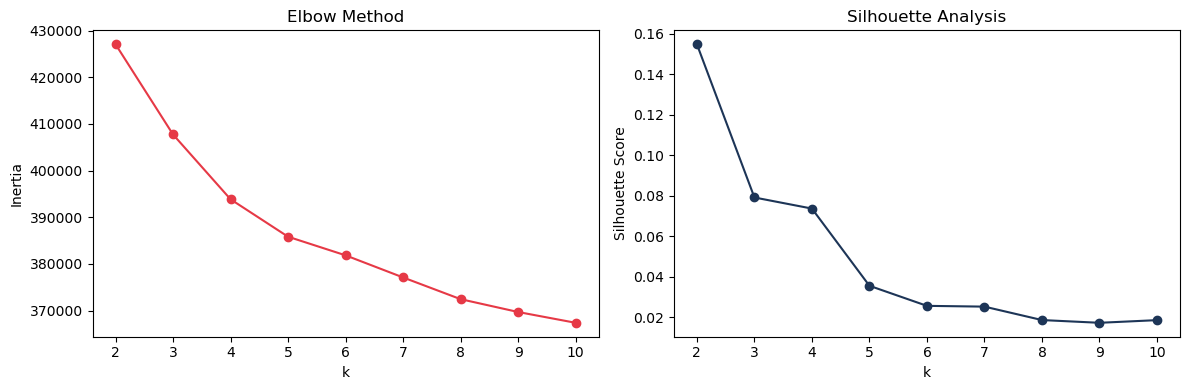

In [7]:
# Test different values of k
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker="o", color="#e63946")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(k_range, silhouettes, marker="o", color="#1d3557")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")

plt.tight_layout()
plt.show()

## Clustering: K-Means with k=4

In [9]:
# Final clustering with optimal k
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
data_filled["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(data_filled["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    1437
1    1126
2    1732
3     705
Name: count, dtype: int64


/var/folders/zx/zwc46x_x7156lj4w_1s2x7m80000gp/T/ipykernel_15936/3415396671.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_filled["cluster"] = kmeans.fit_predict(X_scaled)


## Cluster Profiles: Top Movies per Segment

In [11]:
# Analyze each cluster's movie preferences
cluster_means = data_filled.groupby("cluster")[X.columns].mean()

for cluster in range(4):
    top5 = cluster_means.loc[cluster].nlargest(5)
    print(f"\n--- Cluster {cluster} ---")
    for movie, rating in top5.items():
        print(f"  {movie}: {rating:.2f}")


--- Cluster 0 ---
  Raiders of the Lost Ark: 4.56
  Lord of the Rings: The Fellowship of the Ring: 4.45
  The Shawshank Redemption: Special Edition: 4.44
  Pulp Fiction: 4.44
  The Silence of the Lambs: 4.41

--- Cluster 1 ---
  The Sixth Sense: 4.11
  Raiders of the Lost Ark: 4.05
  Forrest Gump: 4.00
  Pirates of the Caribbean: The Curse of the Black Pearl: 3.90
  Independence Day: 3.90

--- Cluster 2 ---
  Forrest Gump: 4.60
  Braveheart: 4.58
  Lord of the Rings: The Two Towers: 4.58
  Lord of the Rings: The Fellowship of the Ring: 4.58
  The Sixth Sense: 4.58

--- Cluster 3 ---
  Raiders of the Lost Ark: 3.70
  Pulp Fiction: 3.68
  The Silence of the Lambs: 3.65
  The Shawshank Redemption: Special Edition: 3.35
  The Sixth Sense: 3.34


## Cluster Visualization: Heatmap

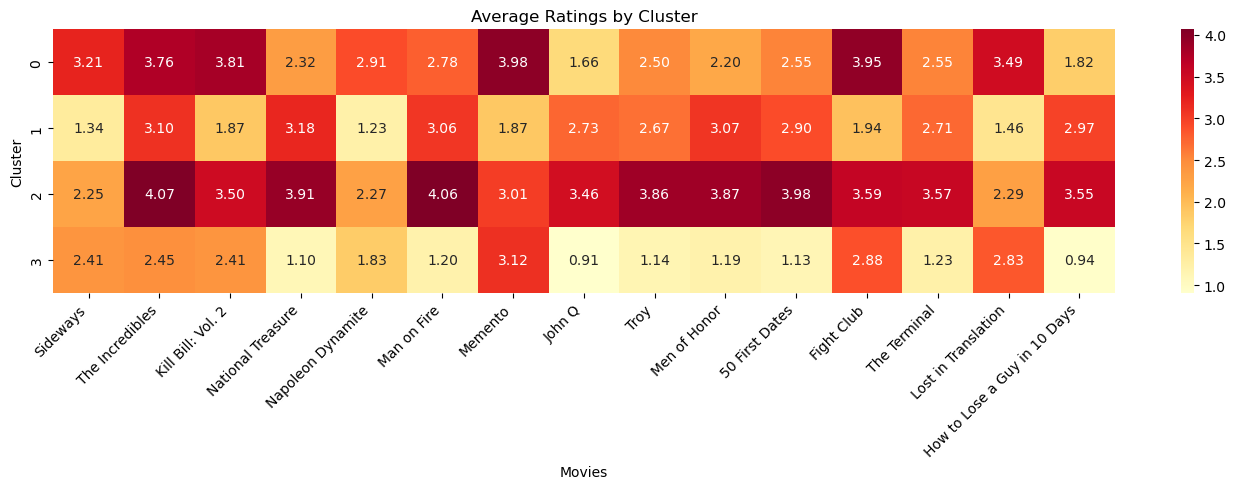

In [13]:
# Heatmap of top 15 most variable movies across clusters
import seaborn as sns

top_movies = X.var().nlargest(15).index
heatmap_data = cluster_means[top_movies]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlOrRd", fmt=".2f")
plt.xlabel("Movies")
plt.ylabel("Cluster")
plt.title("Average Ratings by Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()